# 1. Perkenalan Dataset

**Nama:** Mursyid Dwi Wahidiyantoro  
**Username Dicoding:** `mursyiddwiw`  
**Kelas:** Membangun Sistem Machine Learning  
**Dataset:** Heart Disease UCI (Cleveland Dataset)  
**Sumber:** UCI Machine Learning Repository / Kaggle  

### Deskripsi Dataset
Dataset ini digunakan untuk memprediksi ada atau tidaknya penyakit jantung koroner pada pasien berdasarkan serangkaian indikator klinis dan hasil tes medis. Dataset terdiri atas 297 baris data tanpa missing value dengan 13 atribut prediktor dan 1 target biner.

**Fitur-fitur Dataset:**
1. `age`: Usia pasien dalam tahun.
2. `sex`: Jenis kelamin (1 = laki-laki; 0 = perempuan).
3. `cp`: Tipe nyeri dada (Chest Pain Type: 1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic).
4. `trestbps`: Tekanan darah istirahat (Resting blood pressure dalam mm Hg saat masuk rumah sakit).
5. `chol`: Kolesterol serum dalam mg/dl.
6. `fbs`: Gula darah puasa > 120 mg/dl (1 = true; 0 = false).
7. `restecg`: Hasil elektrokardiografi istirahat (0 = normal, 1 = memiliki kelainan gelombang ST-T, 2 = menunjukkan hipertrofi ventrikel kiri).
8. `thalach`: Denyut jantung maksimum yang dicapai.
9. `exang`: Angina yang diinduksi oleh latihan (1 = ya; 0 = tidak).
10. `oldpeak`: Depresi ST yang diinduksi oleh latihan relatif terhadap istirahat.
11. `slope`: Kemiringan segmen ST latihan puncak (1 = upsloping, 2 = flat, 3 = downsloping).
12. `ca`: Jumlah pembuluh darah utama (0-3) yang diwarnai dengan fluoroskopi.
13. `thal`: Status thalium scan (3 = normal; 6 = fixed defect; 7 = reversable defect).
14. `target`: Diagnosis penyakit jantung (0 = tidak ada penyakit jantung, 1 = ada penyakit jantung).


# 2. Import Library

Pada tahap ini, kita mengimpor library yang dibutuhkan untuk analisis data, visualisasi, dan data preprocessing.


In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Set aesthetic visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("Seluruh library berhasil di-import dengan sukses.")


Seluruh library berhasil di-import dengan sukses.


# 3. Memuat Dataset

Pada tahap ini, dataset dimuat dari file `heart_raw.csv`. Kita memeriksa bentuk dataset, lima baris pertama, dan informasi tipe data kolom.


In [2]:
# Memuat raw dataset
raw_data_path = '../heart_raw.csv'
if not os.path.exists(raw_data_path):
    raw_data_path = 'heart_raw.csv'

df = pd.read_csv(raw_data_path)
print(f"Dimensi dataset: {df.shape[0]} baris x {df.shape[1]} kolom")
df.head()


Dimensi dataset: 297 baris x 14 kolom


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0.0,6.0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3.0,3.0,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2.0,7.0,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0.0,3.0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0.0,3.0,0


In [3]:
# Informasi tipe data dan memori
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    int64  
 2   cp        297 non-null    int64  
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    int64  
 6   restecg   297 non-null    int64  
 7   thalach   297 non-null    float64
 8   exang     297 non-null    int64  
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    int64  
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(7), int64(7)
memory usage: 32.6 KB


# 4. Exploratory Data Analysis (EDA)

Pada tahap ini, dilakukan eksplorasi data untuk memahami karakteristik distribusi statistik, proporsi target, korelasi antar fitur, serta mendeteksi potensi anomali atau outlier.


In [4]:
# Statistik deskriptif seluruh fitur numerik
df.describe().round(2)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00
mean,54.54,0.68,3.16,131.69,247.35,0.14,1.00,149.60,0.33,1.06,1.60,0.68,4.73,0.46
std,9.05,0.47,0.96,17.76,52.00,0.35,0.99,22.94,0.47,1.17,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.00,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,243.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,276.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


Distribusi Target:
0    160
1    137
Name: target, dtype: int64


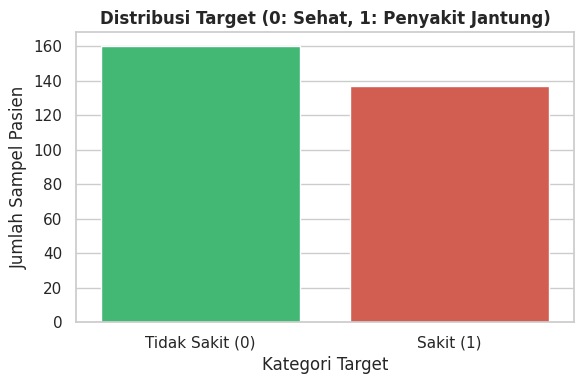

In [5]:
# Analisis distribusi variabel target
target_counts = df['target'].value_counts()
print("Distribusi Target:")
print(target_counts)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette=['#2ecc71', '#e74c3c'])
plt.title("Distribusi Target (0: Sehat, 1: Penyakit Jantung)", fontsize=12, fontweight='bold')
plt.xlabel("Kategori Target")
plt.ylabel("Jumlah Sampel Pasien")
plt.xticks([0, 1], ['Tidak Sakit (0)', 'Sakit (1)'])
plt.tight_layout()
plt.show()


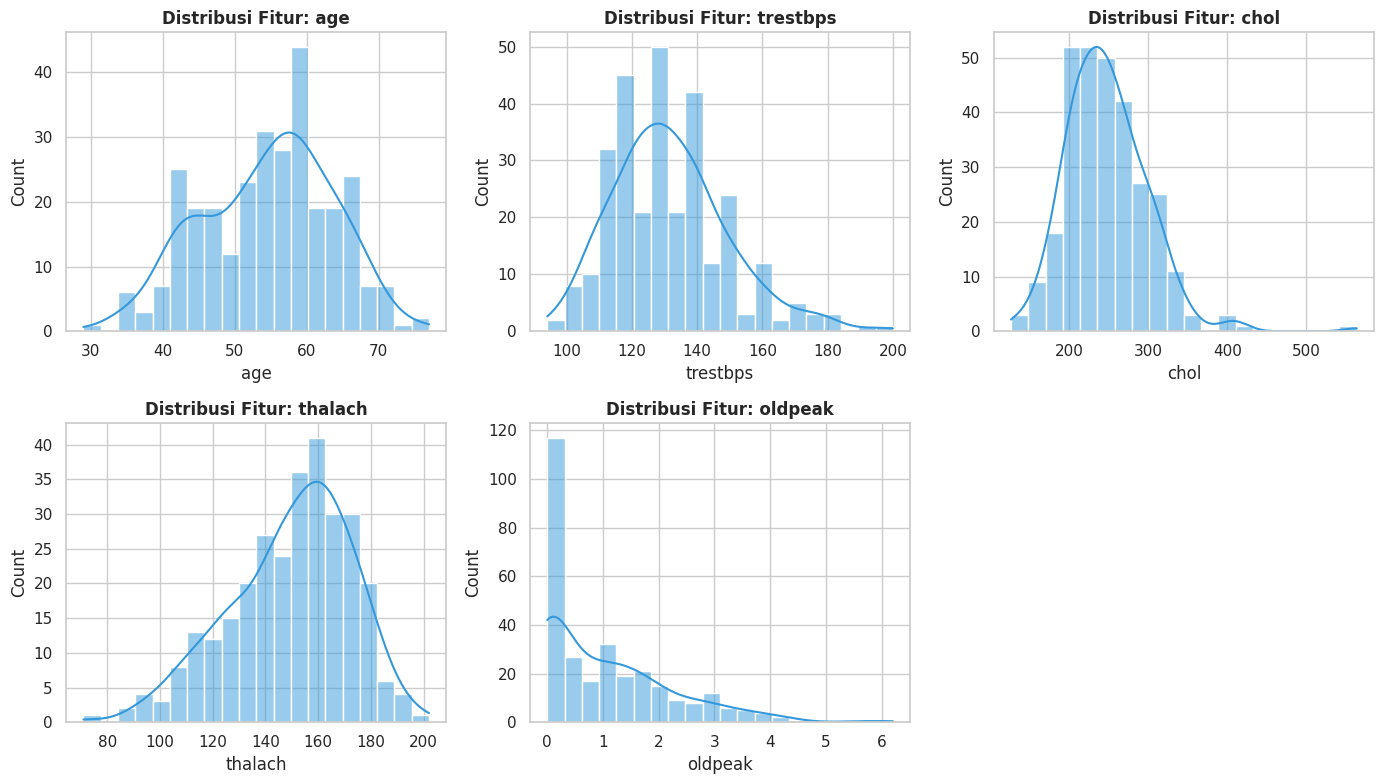

In [6]:
# Distribusi fitur numerik kontinu
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(continuous_features):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='#3498db', bins=20)
    axes[idx].set_title(f"Distribusi Fitur: {col}", fontweight='bold')

axes[5].axis('off') # hide redundant subplot
plt.tight_layout()
plt.show()


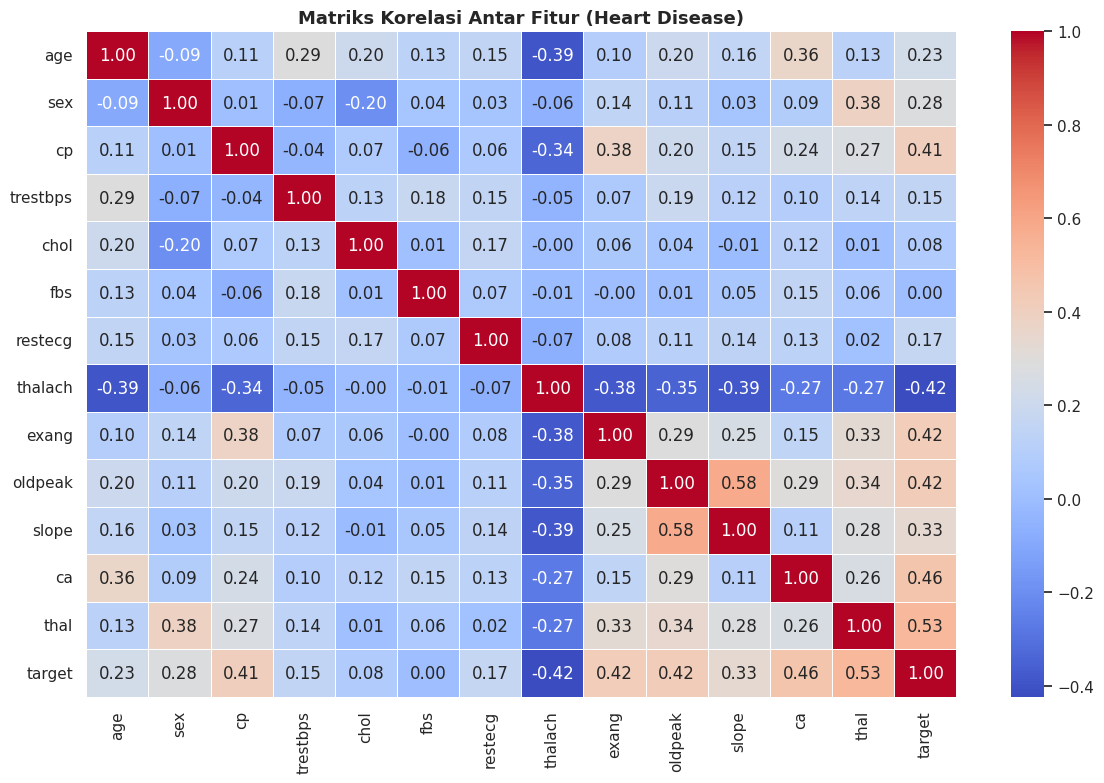

In [7]:
# Korelasi antar fitur terhadap target (Heatmap)
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi Antar Fitur (Heart Disease)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# 5. Data Preprocessing

Pada tahap ini, kita melakukan tahapan data cleaning dan transformasi fitur:
1. Memeriksa dan menangani nilai kosong (missing values) dan duplikat.
2. Deteksi dan penanganan nilai pencilan (outliers) menggunakan metode Interquartile Range (IQR) capping.
3. Standarisasi fitur numerik menggunakan `StandardScaler`.
4. Menyimpan dataset yang telah diproses ke file `heart_preprocessing.csv` untuk digunakan pada tahap pemodelan machine learning.


In [8]:
# 5.1 Cek Missing Values dan Duplikasi
missing = df.isnull().sum().sum()
duplicates = df.duplicated().sum()

print(f"Total missing values : {missing}")
print(f"Total baris duplikat : {duplicates}")

df_clean = df.drop_duplicates().copy()


Total missing values : 0
Total baris duplikat : 0


In [9]:
# 5.2 Penanganan Outlier dengan IQR Capping
print("Rentang nilai sebelum capping:")
for col in continuous_features:
    print(f" - {col}: min={df_clean[col].min():.1f}, max={df_clean[col].max():.1f}")

for col in continuous_features:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df_clean[col] = np.clip(df_clean[col], lower_bound, upper_bound)

print("\nRentang nilai setelah IQR capping:")
for col in continuous_features:
    print(f" - {col}: min={df_clean[col].min():.1f}, max={df_clean[col].max():.1f}")


Rentang nilai sebelum capping:
 - age: min=29.0, max=77.0
 - trestbps: min=94.0, max=200.0
 - chol: min=126.0, max=564.0
 - thalach: min=71.0, max=202.0
 - oldpeak: min=0.0, max=6.2

Rentang nilai setelah IQR capping:
 - age: min=29.0, max=77.0
 - trestbps: min=94.0, max=170.0
 - chol: min=126.0, max=373.5
 - thalach: min=83.5, max=202.0
 - oldpeak: min=0.0, max=4.0


In [10]:
# 5.3 Standarisasi Fitur Numerik Kontinu
scaler = StandardScaler()
df_clean[continuous_features] = scaler.fit_transform(df_clean[continuous_features])

print("Hasil standarisasi (Mean ~ 0, Std ~ 1):")
for col in continuous_features:
    print(f" - {col}: mean={df_clean[col].mean():.2f}, std={df_clean[col].std():.2f}")
df_clean.head()


Hasil standarisasi (Mean ~ 0, Std ~ 1):
 - age: mean=-0.00, std=1.00
 - trestbps: mean=-0.00, std=1.00
 - chol: mean=0.00, std=1.00
 - thalach: mean=-0.00, std=1.00
 - oldpeak: mean=0.00, std=1.00


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.936181,1,1,0.814195,-0.277680,1,2,0.015748,0,1.132325,3,0.0,6.0,0
1,1.378929,1,4,1.708484,0.832124,0,2,-1.828822,1,0.413350,2,3.0,3.0,1
2,1.378929,1,4,-0.676288,-0.361439,0,2,-0.906537,1,1.401940,2,2.0,7.0,1
3,-1.941680,1,3,-0.080095,0.078295,0,0,1.640727,0,2.210787,3,0.0,3.0,0
4,-1.498933,0,2,-0.080095,-0.884932,0,2,0.981952,0,0.323478,1,0.0,3.0,0


In [11]:
# 5.4 Ekspor Hasil Preprocessing
output_file = 'heart_preprocessing.csv'
df_clean.to_csv(output_file, index=False)
print(f"Dataset hasil preprocessing berhasil disimpan ke: {output_file}")
print(f"Dimensi akhir: {df_clean.shape}")


Dataset hasil preprocessing berhasil disimpan ke: heart_preprocessing.csv
Dimensi akhir: (297, 14)
